In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# For models
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf

plt.style.use("seaborn-v0_8")

# --- Config ---
TICKER = "NVDA"
SPY = "^GSPC"
YEARS = 5

END_DATE = datetime.today().strftime("%Y-%m-%d")
START_DATE = (datetime.today() - timedelta(days=YEARS * 365)).strftime("%Y-%m-%d")

print(f"Fetching data for {TICKER} from {START_DATE} to {END_DATE}")

# --- Download Data ---
nvda_df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)
spy_df = yf.download(SPY, start=START_DATE, end=END_DATE, progress=False)

# Flatten columns if MultiIndex
if isinstance(nvda_df.columns, pd.MultiIndex):
    nvda_df.columns = ['_'.join(col).strip() for col in nvda_df.columns.values]
if isinstance(spy_df.columns, pd.MultiIndex):
    spy_df.columns = ['_'.join(col).strip() for col in spy_df.columns.values]


Fetching data for NVDA from 2020-10-16 to 2025-10-15


/tmp/ipython-input-2858112799.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda_df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)
/tmp/ipython-input-2858112799.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_df = yf.download(SPY, start=START_DATE, end=END_DATE, progress=False)


In [ ]:
print(nvda_df.head())
print(nvda_df.describe().T)
print(f"Missing values:\n{nvda_df.isna().sum()}")


            Close_NVDA  High_NVDA   Low_NVDA  Open_NVDA  Volume_NVDA
Date                                                                
2020-10-16   13.769467  14.078524  13.750525  13.994032    242392000
2020-10-19   13.456671  13.940942  13.365947  13.860687    298068000
2020-10-20   13.603972  13.757753  13.465894  13.542161    229212000
2020-10-21   13.483590  13.749529  13.436484  13.583535    219596000
2020-10-22   13.320338  13.570325  13.191481  13.481347    290480000
              count          mean           std           min           25%           50%           75%           max
Close_NVDA   1254.0  5.980108e+01  5.256767e+01  1.121353e+01  1.782092e+01  3.014194e+01  1.096379e+02  1.925700e+02
High_NVDA    1254.0  6.083249e+01  5.336600e+01  1.172092e+01  1.809638e+01  3.063599e+01  1.125532e+02  1.956200e+02
Low_NVDA     1254.0  5.865010e+01  5.167787e+01  1.080003e+01  1.740411e+01  2.952764e+01  1.066918e+02  1.910600e+02
Open_NVDA    1254.0  5.979426e+01  5.259787e+

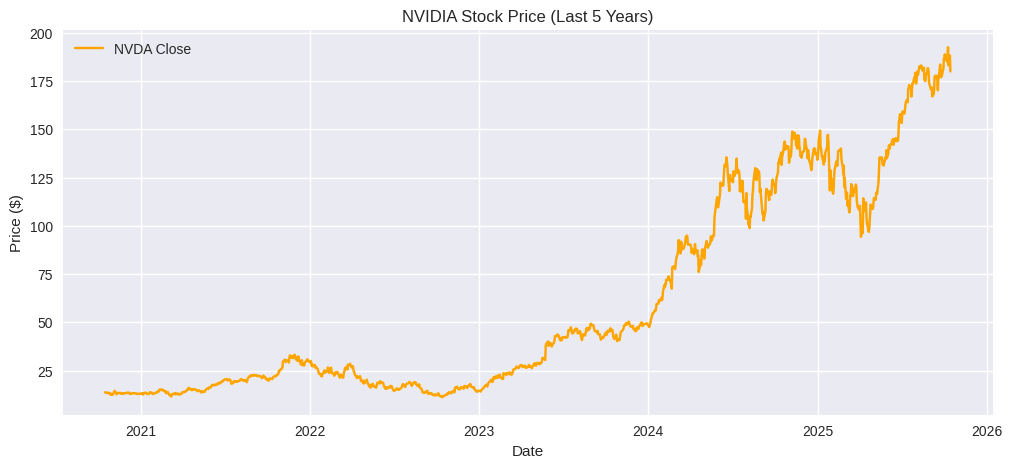

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(nvda_df.index, nvda_df['Close_NVDA'], label='NVDA Close', color='orange')
plt.title("NVIDIA Stock Price (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()


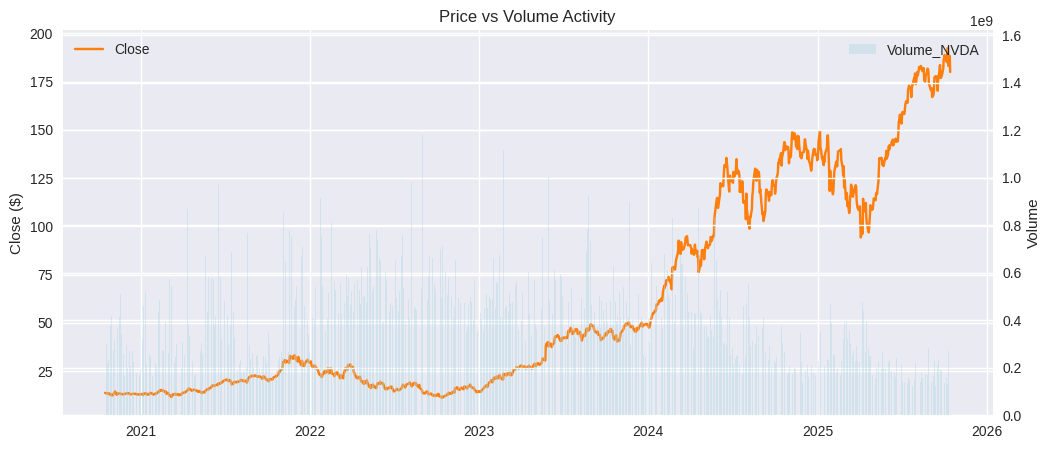

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(nvda_df.index, nvda_df['Close_NVDA'], color='tab:orange', label='Close')
ax2 = ax1.twinx()
ax2.bar(nvda_df.index, nvda_df['Volume_NVDA'], color='lightblue', alpha=0.4, label='Volume_NVDA')
ax1.set_title("Price vs Volume Activity")
ax1.set_ylabel("Close ($)")
ax2.set_ylabel("Volume")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()


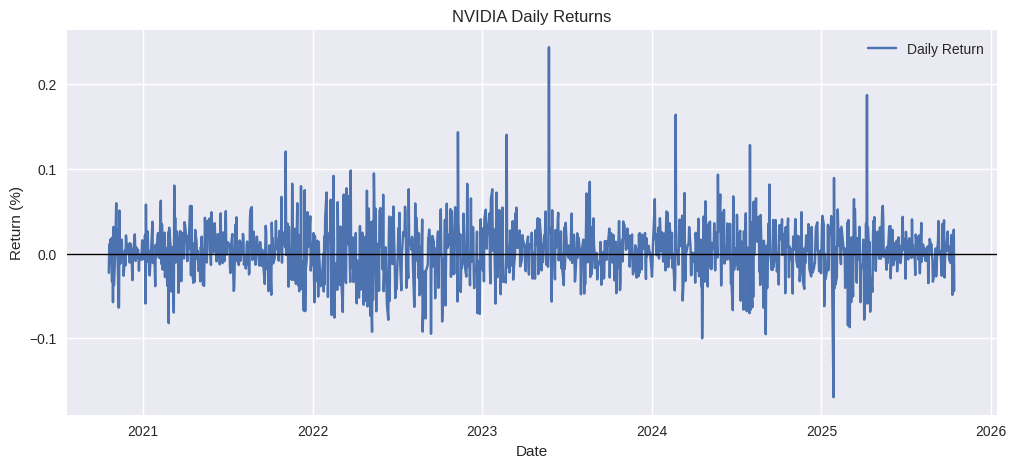

Volatility (std of daily returns): 0.03295776190687299


In [ ]:
nvda_df['Daily_Return'] = nvda_df['Close_NVDA'].pct_change()
plt.figure(figsize=(12, 5))
plt.plot(nvda_df['Daily_Return'], label='Daily Return')
plt.axhline(0, color='black', linewidth=1)
plt.title("NVIDIA Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.show()

print("Volatility (std of daily returns):", nvda_df['Daily_Return'].std())


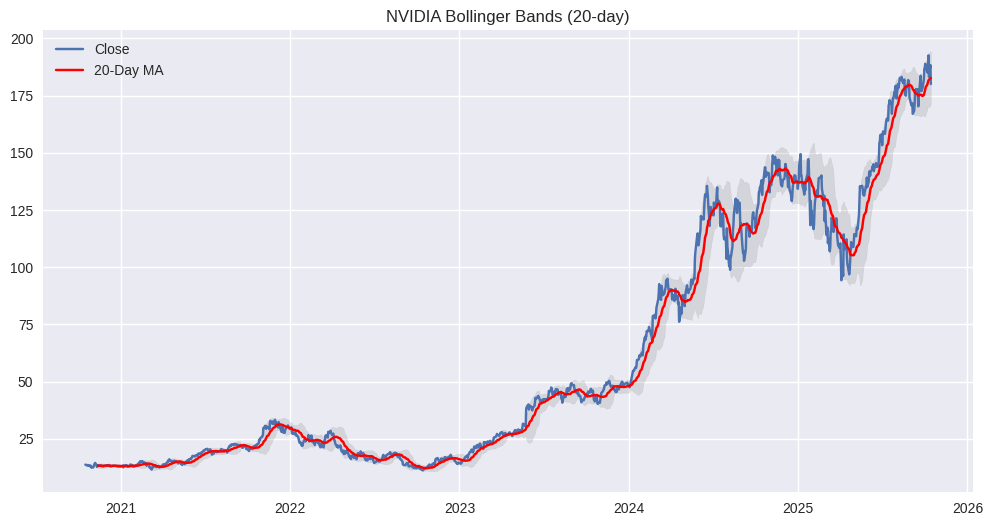

In [ ]:
nvda_df['MA20'] = nvda_df['Close_NVDA'].rolling(20).mean()
nvda_df['Upper'] = nvda_df['MA20'] + 2 * nvda_df['Close_NVDA'].rolling(20).std()
nvda_df['Lower'] = nvda_df['MA20'] - 2 * nvda_df['Close_NVDA'].rolling(20).std()

plt.figure(figsize=(12, 6))
plt.plot(nvda_df['Close_NVDA'], label='Close')
plt.plot(nvda_df['MA20'], label='20-Day MA', color='red')
plt.fill_between(nvda_df.index, nvda_df['Upper'], nvda_df['Lower'], color='gray', alpha=0.2)
plt.title("NVIDIA Bollinger Bands (20-day)")
plt.legend()
plt.show()


In [ ]:
nvda_df.reset_index(inplace=True)
spy_df.reset_index(inplace=True)

In [ ]:
# Ensure column exists
if 'Date' in nvda_df.columns:
    nvda_df['Date'] = pd.to_datetime(nvda_df['Date'])
    nvda_df.set_index('Date', inplace=True)


In [ ]:
if 'Date' in spy_df.columns:
    spy_df['Date'] = pd.to_datetime(spy_df['Date'])
    spy_df.set_index('Date', inplace=True)


In [ ]:
print(merged.index.name)
print(type(merged.index))
print(merged.head())


Date
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
            Open_NVDA  High_NVDA   Low_NVDA          y    SPY_Close   Date_col     y_log
Date                                                                                    
2020-10-16  13.994032  14.078524  13.750525  13.769467  3483.810059 2020-10-16  2.692562
2020-10-19  13.860687  13.940942  13.365947  13.456671  3426.919922 2020-10-19  2.671156
2020-10-20  13.542161  13.757753  13.465894  13.603972  3443.120117 2020-10-20  2.681294
2020-10-21  13.583535  13.749529  13.436484  13.483590  3435.560059 2020-10-21  2.673016
2020-10-22  13.481347  13.570325  13.191481  13.320338  3453.489990 2020-10-22  2.661681


DATA PREP


PROPHET

ERROR FREE - stepwise


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from prophet import Prophet

# change display options for clarity
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

YEARS = 5
END_DATE = datetime.today().strftime("%Y-%m-%d")
START_DATE = (datetime.today() - timedelta(days=YEARS * 365)).strftime("%Y-%m-%d")

print("Using date range:", START_DATE, "to", END_DATE)


Using date range: 2020-10-16 to 2025-10-15


In [ ]:
nvda = yf.download("NVDA", start=START_DATE, end=END_DATE, progress=False)

print("NVDA head (index & cols):")
print(nvda.head())
print(nvda.columns)
print("SPY head (index & cols):")
print(spy.head())
print(spy.columns)

# ---------------------- FETCH & CLEAN SPY ----------------------
spy = yf.download("^GSPC", start=START_DATE, end=END_DATE, progress=False)

# Flatten multi-index columns if any
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = ['_'.join(col).strip() for col in spy.columns.values]

# Rename Close column cleanly
if 'Close_^GSPC' in spy.columns:
    spy.rename(columns={'Close_^GSPC': 'SPY_Close'}, inplace=True)
elif 'Close' in spy.columns:
    spy.rename(columns={'Close': 'SPY_Close'}, inplace=True)

# Reset index
spy.reset_index(inplace=True)

# Fill any missing SPY_Close (rare)
spy['SPY_Close'] = spy['SPY_Close'].ffill().bfill()



NVDA head (index & cols):
Price           Close       High        Low       Open     Volume
Ticker           NVDA       NVDA       NVDA       NVDA       NVDA
Date                                                             
2020-10-16  13.769467  14.078524  13.750525  13.994032  242392000
2020-10-19  13.456671  13.940942  13.365947  13.860687  298068000
2020-10-20  13.603972  13.757753  13.465894  13.542161  229212000
2020-10-21  13.483590  13.749529  13.436484  13.583535  219596000
2020-10-22  13.320338  13.570325  13.191481  13.481347  290480000
MultiIndex([( 'Close', 'NVDA'),
            (  'High', 'NVDA'),
            (   'Low', 'NVDA'),
            (  'Open', 'NVDA'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])
SPY head (index & cols):
   index       Date    SPY_Close   High_^GSPC    Low_^GSPC   Open_^GSPC  Volume_^GSPC
0      0 2020-10-16  3483.810059  3515.760010  3480.449951  3493.500000    4688030000
1      1 2020-10-19  3426.919922  3502.419922  341

/tmp/ipython-input-1062483327.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda = yf.download("NVDA", start=START_DATE, end=END_DATE, progress=False)
/tmp/ipython-input-1062483327.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("^GSPC", start=START_DATE, end=END_DATE, progress=False)


In [ ]:
import numpy as np
import pandas as pd

def clean_and_fill_missing(df, window=5):
    """
    Cleans NaN, null-like strings, and blanks in a DataFrame.
    Then fills numeric columns using local mean of up to 5 preceding
    and succeeding non-null values.
    """

    df = df.copy()

    # --- STEP 1: Replace all string placeholders with np.nan ---
    null_like = ['null', 'NULL', 'NaN', 'nan', '-', '--', ' ', '', 'None', 'none']
    df.replace(null_like, np.nan, inplace=True)

    # Convert strings that look like numbers to numeric (coerce)
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = pd.to_numeric(df[col], errors='ignore')

    # --- STEP 2: For numeric columns, apply rolling mean fill ---
    for col in df.columns:
        if np.issubdtype(df[col].dtype, np.number):
            n_missing = df[col].isna().sum()
            if n_missing > 0:
                print(f"⚠️ Filling {n_missing} missing in numeric column '{col}' with local mean ±{window} window")
                fwd = df[col].fillna(method='ffill', limit=window)
                bwd = df[col].fillna(method='bfill', limit=window)
                df[col] = (fwd + bwd) / 2.0
                # Fill remaining edges with column mean
                df[col].fillna(df[col].mean(), inplace=True)

        else:
            # --- STEP 3: For non-numeric columns, forward fill then backward fill ---
            if df[col].isna().sum() > 0:
                df[col].fillna(method='ffill', inplace=True)
                df[col].fillna(method='bfill', inplace=True)

    return df


# Clean and fill both
nvda = clean_and_fill_missing(nvda, window=5)
spy = clean_and_fill_missing(spy, window=5)

print("✅ Cleaned NVDA and SPY data. Remaining NaNs:")
print("NVDA:", nvda.isna().sum().sum(), " | SPY:", spy.isna().sum().sum())


✅ Cleaned NVDA and SPY data. Remaining NaNs:
NVDA: 0  | SPY: 0


In [ ]:
def flatten_if_multiindex(df):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join([str(c) for c in col]).strip() for col in df.columns.values]
    return df

nvda = flatten_if_multiindex(nvda)
spy  = flatten_if_multiindex(spy)

print("Post-flatten NVDA columns:", nvda.columns.tolist())
print("Post-flatten SPY columns:", spy.columns.tolist())


Post-flatten NVDA columns: ['Close_NVDA', 'High_NVDA', 'Low_NVDA', 'Open_NVDA', 'Volume_NVDA']
Post-flatten SPY columns: ['Date', 'SPY_Close', 'High_^GSPC', 'Low_^GSPC', 'Open_^GSPC', 'Volume_^GSPC']


In [ ]:
nvda = nvda.reset_index()
spy  = spy.reset_index()

print("NVDA sample rows with Date column:")
print(nvda.head())
print("SPY sample rows with Date column:")
print(spy.head())


NVDA sample rows with Date column:
        Date  Close_NVDA  High_NVDA   Low_NVDA  Open_NVDA  Volume_NVDA
0 2020-10-16   13.769467  14.078524  13.750525  13.994032    242392000
1 2020-10-19   13.456671  13.940942  13.365947  13.860687    298068000
2 2020-10-20   13.603972  13.757753  13.465894  13.542161    229212000
3 2020-10-21   13.483590  13.749529  13.436484  13.583535    219596000
4 2020-10-22   13.320338  13.570325  13.191481  13.481347    290480000
SPY sample rows with Date column:
   index       Date    SPY_Close   High_^GSPC    Low_^GSPC   Open_^GSPC  Volume_^GSPC
0      0 2020-10-16  3483.810059  3515.760010  3480.449951  3493.500000    4688030000
1      1 2020-10-19  3426.919922  3502.419922  3419.929932  3493.659912    4091080000
2      2 2020-10-20  3443.120117  3476.929932  3435.649902  3439.379883    3917850000
3      3 2020-10-21  3435.560059  3464.860107  3433.060059  3439.909912    4103960000
4      4 2020-10-22  3453.489990  3460.530029  3415.340088  3438.500000    

In [ ]:
# choose which stock cols to keep
nvda_sub = nvda[['Date', 'Open_NVDA', 'High_NVDA', 'Low_NVDA', 'Close_NVDA']].copy()
spy_sub  = spy[['Date', 'SPY_Close']].copy().rename(columns={'Close': 'SPY_Close'})

merged = pd.merge(nvda_sub, spy_sub, on='Date', how='inner')
print("Merged (head):")
print(merged.head())
print("Merged columns:", merged.columns.tolist())


Merged (head):
        Date  Open_NVDA  High_NVDA   Low_NVDA  Close_NVDA    SPY_Close
0 2020-10-16  13.994032  14.078524  13.750525   13.769467  3483.810059
1 2020-10-19  13.860687  13.940942  13.365947   13.456671  3426.919922
2 2020-10-20  13.542161  13.757753  13.465894   13.603972  3443.120117
3 2020-10-21  13.583535  13.749529  13.436484   13.483590  3435.560059
4 2020-10-22  13.481347  13.570325  13.191481   13.320338  3453.489990
Merged columns: ['Date', 'Open_NVDA', 'High_NVDA', 'Low_NVDA', 'Close_NVDA', 'SPY_Close']


In [ ]:
merged['Date_col'] = merged['Date']              # visible column for Prophet later
merged.set_index('Date', inplace=True)          # index for time series ops
print("After setting index: index name =", merged.index.name)
print("Columns now:", merged.columns.tolist())
print(merged.head())


After setting index: index name = Date
Columns now: ['Open_NVDA', 'High_NVDA', 'Low_NVDA', 'Close_NVDA', 'SPY_Close', 'Date_col']
            Open_NVDA  High_NVDA   Low_NVDA  Close_NVDA    SPY_Close   Date_col
Date                                                                           
2020-10-16  13.994032  14.078524  13.750525   13.769467  3483.810059 2020-10-16
2020-10-19  13.860687  13.940942  13.365947   13.456671  3426.919922 2020-10-19
2020-10-20  13.542161  13.757753  13.465894   13.603972  3443.120117 2020-10-20
2020-10-21  13.583535  13.749529  13.436484   13.483590  3435.560059 2020-10-21
2020-10-22  13.481347  13.570325  13.191481   13.320338  3453.489990 2020-10-22


In [ ]:
# If there's a 'y' rename needed, create it from Close
if 'y' not in merged.columns:
    # prefer existing 'Close' column
    if 'Close' in merged.columns:
        merged.rename(columns={'Close': 'y'}, inplace=True)
    else:
        # attempt to find a candidate close-like column
        candidates = [c for c in merged.columns if 'close' in c.lower()]
        if candidates:
            merged.rename(columns={candidates[0]: 'y'}, inplace=True)

print("Post-rename columns:", merged.columns.tolist())

# Remove duplicated column names entirely (keep first)
merged = merged.loc[:, ~merged.columns.duplicated()]
print("After dropping duplicated-named columns:", merged.columns.tolist())

# Diagnostic: show type of merged['y']
print("Type of merged['y']:", type(merged['y']))
print("Sample merged[['y','SPY_Close','Date_col']]:")
print(merged[['y','SPY_Close','Date_col']].head())


Post-rename columns: ['Open_NVDA', 'High_NVDA', 'Low_NVDA', 'y', 'SPY_Close', 'Date_col']
After dropping duplicated-named columns: ['Open_NVDA', 'High_NVDA', 'Low_NVDA', 'y', 'SPY_Close', 'Date_col']
Type of merged['y']: <class 'pandas.core.series.Series'>
Sample merged[['y','SPY_Close','Date_col']]:
                    y    SPY_Close   Date_col
Date                                         
2020-10-16  13.769467  3483.810059 2020-10-16
2020-10-19  13.456671  3426.919922 2020-10-19
2020-10-20  13.603972  3443.120117 2020-10-20
2020-10-21  13.483590  3435.560059 2020-10-21
2020-10-22  13.320338  3453.489990 2020-10-22


In [ ]:
# If somehow merged['y'] is a DataFrame (2D), pick first numeric column
if isinstance(merged['y'], pd.DataFrame):
    print("WARNING: 'y' is a DataFrame. Flattening by taking first column.")
    merged['y'] = merged['y'].iloc[:, 0]

# coerce to numeric (forces strings -> NaN)
merged['y'] = pd.to_numeric(merged['y'], errors='coerce')
merged['SPY_Close'] = pd.to_numeric(merged['SPY_Close'], errors='coerce')

# also ensure Date_col is datetime
merged['Date_col'] = pd.to_datetime(merged['Date_col'], errors='coerce')

# drop rows with missing essential values
merged.dropna(subset=['Date_col', 'y', 'SPY_Close'], inplace=True)

print("After coercion/dropping nulls - head:")
print(merged[['y','SPY_Close','Date_col']].head())
print("dtypes:\n", merged[['y','SPY_Close','Date_col']].dtypes)


After coercion/dropping nulls - head:
                    y    SPY_Close   Date_col
Date                                         
2020-10-16  13.769467  3483.810059 2020-10-16
2020-10-19  13.456671  3426.919922 2020-10-19
2020-10-20  13.603972  3443.120117 2020-10-20
2020-10-21  13.483590  3435.560059 2020-10-21
2020-10-22  13.320338  3453.489990 2020-10-22
dtypes:
 y                   float64
SPY_Close           float64
Date_col     datetime64[ns]
dtype: object


In [ ]:
TEST_DAYS = 90
test_start_date = merged.index[-TEST_DAYS]   # index is Date
print("test_start_date:", test_start_date)

train_df = merged[merged.index < test_start_date].copy()
test_df  = merged[merged.index >= test_start_date].copy()

# Prepare DataFrame for Prophet: columns ds, y, SPY_Close
train_for_prophet = train_df[['Date_col', 'y', 'SPY_Close','Open_NVDA', 'High_NVDA', 'Low_NVDA']].copy()
train_for_prophet.rename(columns={'Date_col': 'ds'}, inplace=True)

print("Train for prophet head and dtypes:")
print(train_for_prophet.head())
print(train_for_prophet.dtypes)


test_start_date: 2025-06-06 00:00:00
Train for prophet head and dtypes:
                   ds          y    SPY_Close  Open_NVDA  High_NVDA   Low_NVDA
Date                                                                          
2020-10-16 2020-10-16  13.769467  3483.810059  13.994032  14.078524  13.750525
2020-10-19 2020-10-19  13.456671  3426.919922  13.860687  13.940942  13.365947
2020-10-20 2020-10-20  13.603972  3443.120117  13.542161  13.757753  13.465894
2020-10-21 2020-10-21  13.483590  3435.560059  13.583535  13.749529  13.436484
2020-10-22 2020-10-22  13.320338  3453.489990  13.481347  13.570325  13.191481
ds           datetime64[ns]
y                   float64
SPY_Close           float64
Open_NVDA           float64
High_NVDA           float64
Low_NVDA            float64
dtype: object


In [ ]:
# Verify 'ds' is datetime, 'y' and 'SPY_Close' are numeric and 1D
assert 'ds' in train_for_prophet.columns, "ds missing"
assert 'y' in train_for_prophet.columns, "y missing"
assert train_for_prophet['ds'].dtype.kind in ('M',), "ds not datetime"
assert train_for_prophet['y'].dtype.kind in ('f','i'), "y not numeric"
assert train_for_prophet['SPY_Close'].dtype.kind in ('f','i'), "SPY_Close not numeric"

print("Safety checks passed. Ready to fit Prophet.")


Safety checks passed. Ready to fit Prophet.


In [ ]:
train_for_prophet

,ds,y,SPY_Close,Open_NVDA,High_NVDA,Low_NVDA
Date,,,,,,
2020-10-16,2020-10-16,13.769467,3483.810059,13.994032,14.078524,13.750525
2020-10-19,2020-10-19,13.456671,3426.919922,13.860687,13.940942,13.365947
2020-10-20,2020-10-20,13.603972,3443.120117,13.542161,13.757753,13.465894
2020-10-21,2020-10-21,13.483590,3435.560059,13.583535,13.749529,13.436484
2020-10-22,2020-10-22,13.320338,3453.489990,13.481347,13.570325,13.191481
...,...,...,...,...,...,...
2025-05-30,2025-05-30,135.113007,5911.689941,138.702551,139.602432,132.903278
2025-06-02,2025-06-02,137.362717,5935.939941,135.472955,138.102614,135.382955
2025-06-03,2025-06-03,141.202225,5970.370117,138.762529,141.982125,137.932632


In [ ]:
# Ensure no NaN in SPY_Close
merged = merged.where(pd.notnull(merged), None)
merged = merged.dropna(subset=['SPY_Close'])


In [ ]:
null_like = ['nan', 'null', 'none', '-', '', ' ']
mask_any_nan = merged['SPY_Close'].isna() | merged['SPY_Close'].astype(str).str.strip().str.lower().isin(null_like)

print("Total suspicious/NaN-like values:", mask_any_nan.sum())
print(merged.loc[mask_any_nan])


Total suspicious/NaN-like values: 0
Empty DataFrame
Columns: [Open_NVDA, High_NVDA, Low_NVDA, y, SPY_Close, Date_col]
Index: []


In [ ]:
m = Prophet()
m.add_regressor('SPY_Close')

m.fit(train_for_prophet)   # should succeed now
future = m.make_future_dataframe(periods=len(test_df), freq='D')

# Use trading calendar from NVDA data instead of calendar days
future = pd.DataFrame({'ds': pd.concat([train_for_prophet['ds'], test_df['Date_col']])})
future = future.merge(
    merged[['Date_col', 'SPY_Close']].rename(columns={'Date_col': 'ds'}),
    on='ds',
    how='left'
)
future['SPY_Close'] = future['SPY_Close'].ffill().bfill()


future['SPY_Close'].replace(['NaN', 'null', 'None', '', ' '], np.nan, inplace=True)
future['SPY_Close'] = pd.to_numeric(future['SPY_Close'], errors='coerce')
future['SPY_Close'] = future['SPY_Close'].ffill().bfill()

forecast = m.predict(future)
prophet_pred = forecast.set_index('ds').loc[test_df['Date_col'], 'yhat'].values

from sklearn.metrics import mean_absolute_error, mean_squared_error
prophet_mae = mean_absolute_error(test_df['y'], prophet_pred)
prophet_rmse = mean_squared_error(test_df['y'], prophet_pred)
print("Prophet MAE:", prophet_mae, "RMSE:", prophet_rmse)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8bfguw53/xfoi1qu1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8bfguw53/u2myfbwv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24125', 'data', 'file=/tmp/tmp8bfguw53/xfoi1qu1.json', 'init=/tmp/tmp8bfguw53/u2myfbwv.json', 'output', 'file=/tmp/tmp8bfguw53/prophet_modelo9qhf05o/prophet_model-20251015123730.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:37:30 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:37:30 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/tmp/ipython-input-988914689.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment u

Prophet MAE: 24.551705274044718 RMSE: 705.2208656379843


TUNED

In [ ]:
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------
# 1️⃣ Log-transform target variable
# -------------------------------
train_for_prophet['y_log'] = np.log1p(train_for_prophet['y'])
merged['y_log'] = np.log1p(merged['y'])

# -------------------------------
# 2️⃣ Initialize tuned Prophet model
# -------------------------------
m = Prophet(
    growth='linear',                     # Try 'logistic' if stock saturates
    changepoint_prior_scale=0.5,         # lower → smoother trend, higher → more flexibility
    seasonality_mode='multiplicative',   # better for stock-type data
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Add multiple regressors
m.add_regressor('SPY_Close')
m.add_regressor('Open_NVDA')
m.add_regressor('High_NVDA')
m.add_regressor('Low_NVDA')

# -------------------------------
# 3️⃣ Fit the model
# -------------------------------
train_df_for_fit = train_for_prophet[['ds', 'y_log', 'SPY_Close', 'Open_NVDA', 'High_NVDA', 'Low_NVDA']].copy()
train_df_for_fit.rename(columns={'y_log': 'y'}, inplace=True)

m.fit(train_df_for_fit)
print("✅ Prophet trained successfully with tuned parameters and multiple regressors.")

# -------------------------------
# 4️⃣ Build future DataFrame using trading dates
# -------------------------------
future = pd.DataFrame({'ds': pd.concat([train_for_prophet['ds'], test_df['Date_col']])})

# Add regressors from merged data
future = future.merge(
    merged[['Date_col', 'SPY_Close', 'Open_NVDA', 'High_NVDA', 'Low_NVDA']].rename(columns={'Date_col': 'ds'}),
    on='ds', how='left'
)

# Fill missing regressor values (weekends/holidays)
for col in ['SPY_Close', 'Open_NVDA', 'High_NVDA', 'Low_NVDA']:
    future[col] = future[col].ffill().bfill()

# -------------------------------
# 5️⃣ Predict and invert log transform
# -------------------------------
forecast = m.predict(future)
forecast['yhat_exp'] = np.expm1(forecast['yhat'])  # inverse log1p

# Align test period
aligned_forecast = pd.merge(
    test_df[['Date_col', 'y']],
    forecast[['ds', 'yhat_exp']],
    left_on='Date_col', right_on='ds', how='inner'
)

prophet_pred = aligned_forecast['yhat_exp'].values
actual = aligned_forecast['y'].values

# -------------------------------
# 6️⃣ Evaluate performance
# -------------------------------
prophet_mae = mean_absolute_error(actual, prophet_pred)
prophet_rmse = mean_squared_error(actual, prophet_pred, )
prophet_mape = np.mean(np.abs((actual - prophet_pred) / actual)) * 100
prophet_r2 = r2_score(actual, prophet_pred)

print("\n📊 Tuned Prophet Model Performance")
print(f"MAE : {prophet_mae:.2f}")
print(f"RMSE: {prophet_rmse:.2f}")
print(f"MAPE: {prophet_mape:.2f}%")
print(f"R²  : {prophet_r2:.3f}")


DEBUG:cmdstanpy:input tempfile: /tmp/tmp8bfguw53/z7fv7my7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8bfguw53/81soh8gu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29020', 'data', 'file=/tmp/tmp8bfguw53/z7fv7my7.json', 'init=/tmp/tmp8bfguw53/81soh8gu.json', 'output', 'file=/tmp/tmp8bfguw53/prophet_modelir7irx4_/prophet_model-20251015124841.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:48:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:48:42 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


✅ Prophet trained successfully with tuned parameters and multiple regressors.

📊 Tuned Prophet Model Performance
MAE : 23.73
RMSE: 675.88
MAPE: 13.51%
R²  : -2.755


PROPHET TRAINED


In [ ]:
# Ensure datetime consistency
forecast['ds'] = pd.to_datetime(forecast['ds'])
test_df['Date_col'] = pd.to_datetime(test_df['Date_col'])

# Match only dates present in both (trading days)
merged_eval = pd.merge(
    test_df[['Date_col', 'y']],
    forecast[['ds', 'yhat']],
    left_on='Date_col', right_on='ds',
    how='inner'
)

# Prophet predictions for test period
prophet_pred = merged_eval['yhat'].values
actual = merged_eval['y'].values


In [18]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(merged_eval['residual'], bins=30, kde=True, color='salmon')
plt.title("Residual Distribution — Prophet", fontsize=13)
plt.xlabel("Prediction Error ($)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'merged_eval' is not defined

<Figure size 800x500 with 0 Axes>

ONLY LSTM

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Dates
END_DATE = datetime.today().strftime("%Y-%m-%d")
START_DATE = (datetime.today() - timedelta(days=5*365)).strftime("%Y-%m-%d")

# Download data
nvda = yf.download("NVDA", start=START_DATE, end=END_DATE, progress=False)
spy  = yf.download("^GSPC", start=START_DATE, end=END_DATE, progress=False)

# Keep only relevant columns
nvda = nvda[['Open', 'High', 'Low', 'Close']]
spy = spy[['Close']].rename(columns={'Close': 'SPY_Close'})

# Merge both on Date
df = nvda.merge(spy, left_index=True, right_index=True, how='inner')

print("✅ Data shape:", df.shape)
print(df.head())


/tmp/ipython-input-1721410646.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda = yf.download("NVDA", start=START_DATE, end=END_DATE, progress=False)
/tmp/ipython-input-1721410646.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy  = yf.download("^GSPC", start=START_DATE, end=END_DATE, progress=False)


✅ Data shape: (1254, 5)
Price            Open       High        Low      Close    SPY_Close
Ticker           NVDA       NVDA       NVDA       NVDA        ^GSPC
Date                                                               
2020-10-16  13.994031  14.078523  13.750524  13.769466  3483.810059
2020-10-19  13.860687  13.940942  13.365947  13.456671  3426.919922
2020-10-20  13.542160  13.757752  13.465893  13.603971  3443.120117
2020-10-21  13.583534  13.749528  13.436483  13.483589  3435.560059
2020-10-22  13.481344  13.570322  13.191478  13.320335  3453.489990


In [3]:
df.replace(['NaN', 'null', 'None', '', ' '], np.nan, inplace=True)
df = df.astype(float)
df = df.ffill().bfill()


In [4]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled, index=df.index, columns=df.columns)


In [5]:
SEQ_LEN = 60

def create_sequences(data, target_col_index, seq_len=SEQ_LEN):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, target_col_index])
    return np.array(X), np.array(y)

target_col_index = df.columns.get_loc('Close')
X, y = create_sequences(scaled_df.values, target_col_index)
print("✅ Sequence shapes:", X.shape, y.shape)


✅ Sequence shapes: (1194, 60, 5) (1194, 1)


In [6]:
TEST_DAYS = 90
X_train, X_test = X[:-TEST_DAYS], X[-TEST_DAYS:]
y_train, y_test = y[:-TEST_DAYS], y[-TEST_DAYS:]
dates = df.index[SEQ_LEN:]
dates_train, dates_test = dates[:-TEST_DAYS], dates[-TEST_DAYS:]

print("Train samples:", X_train.shape, " Test samples:", X_test.shape)


Train samples: (1104, 60, 5)  Test samples: (90, 60, 5)


In [7]:
tf.keras.backend.clear_session()

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_split=0.1,
                    epochs=100,
                    batch_size=32,
                    callbacks=[es],
                    verbose=1)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0183 - val_loss: 0.0054
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0016 - val_loss: 0.0043
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 204ms/step - loss: 0.0014 - val_loss: 0.0027
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 241ms/step - loss: 0.0014 - val_loss: 0.0025
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0012 - val_loss: 0.0027
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0011 - val_loss: 0.0027
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - loss: 0.0013 - val_loss: 0.0031
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 9.9588e-04 - val_loss: 0.0045
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0019 - val_loss: 0.0059
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0010 - val_loss: 0.0026
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 7.0230e-04 - val_loss: 0.0030
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/st

In [8]:
y_pred_scaled = model.predict(X_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step


In [12]:
# Flatten multi-level columns
df.columns = ['_'.join(col).strip() for col in df.columns.values]

print("Flattened columns:", df.columns.tolist())


Flattened columns: ['Open_NVDA', 'High_NVDA', 'Low_NVDA', 'Close_NVDA', 'SPY_Close_^GSPC']


In [13]:
# Ensure target_col_index is integer
if not isinstance(target_col_index, (int, np.integer)):
    target_col_index = int(np.where(df.columns == 'Close_NVDA')[0][0])

print("Target column index:", target_col_index)
print("Target column name:", df.columns[target_col_index])


Target column index: 3
Target column name: Close_NVDA


In [14]:
# Predict on test set
y_pred_scaled = model.predict(X_test)

# Create arrays for inverse scaling
inv_test = np.zeros((len(y_test), len(df.columns)))
inv_pred = np.zeros((len(y_pred_scaled), len(df.columns)))

# Insert target values into correct column (now works)
inv_test[:, target_col_index:target_col_index+1] = y_test.reshape(-1, 1)
inv_pred[:, target_col_index:target_col_index+1] = y_pred_scaled.reshape(-1, 1)

# Invert scaling
inv_test = scaler.inverse_transform(inv_test)
inv_pred = scaler.inverse_transform(inv_pred)

# Extract actual and predicted Close prices
actual = inv_test[:, target_col_index]
predicted = inv_pred[:, target_col_index]


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [16]:
mae = mean_absolute_error(actual, predicted)
rmse = mean_squared_error(actual, predicted)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
r2 = r2_score(actual, predicted)

print("\n📊 LSTM Model Performance")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²  : {r2:.3f}")



📊 LSTM Model Performance
MAE : 9.15
RMSE: 100.12
MAPE: 5.24%
R²  : 0.444


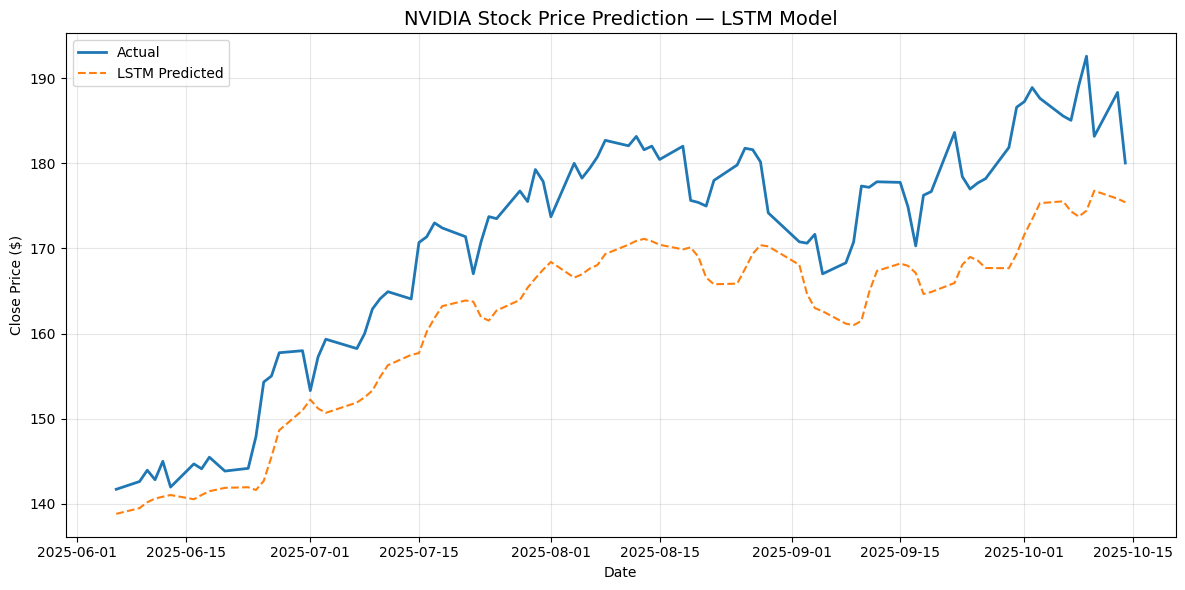

In [17]:
plt.figure(figsize=(12,6))
plt.plot(dates_test, actual, label='Actual', linewidth=2)
plt.plot(dates_test, predicted, label='LSTM Predicted', linestyle='--')
plt.title("NVIDIA Stock Price Prediction — LSTM Model", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
